# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn.preprocessing

from pandas.tseries.offsets import MonthEnd

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [6]:
# Загрузим данные
tracks = pd.read_parquet("data/tracks.parquet")
catalog_names = pd.read_parquet("data/catalog_names.parquet")
interactions = pd.read_parquet("data/interactions.parquet")

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [20]:
# Посмотрим на структуру данных
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [ ]:
# Посмотрим на данные
tracks.sample(3)

,track_id,albums,artists,genres
256586,15876476,[1730681],[226833],"[15, 25]"
738612,55559111,[8133728],"[7749777, 5999454, 6092198, 7749778, 7749779]",[25]
688494,50504756,"[6978053, 10459522]",[6347797],"[3, 75]"


In [ ]:
# Проверим дубликаты
tracks.track_id.duplicated().sum()

0

In [40]:
# Проверим наличие пустых массивов в строках
has_empty_array = tracks[['albums','artists','genres']].apply(lambda row: any(arr.size == 0 for arr in row), axis=1)

# Вывод строк с пустыми массивами
empty_array_rows = tracks[has_empty_array]

print(f'Количество строк с пустыми массивами: {round(empty_array_rows.shape[0]/tracks.shape[0]*100, 2)} %')
display(empty_array_rows)

Количество строк с пустыми массивами: 1.9 %


,track_id,albums,artists,genres
490,2520,"[249, 163801, 163802, 324616, 17542430, 189498...",[2259],[]
3069,16776,"[1479, 5319, 6093, 8467, 10641, 90867, 163801,...",[978],[]
3077,16801,"[1479, 163801, 9287549, 9377183, 9424994, 1201...",[10520],[]
4192,23752,"[2001, 3722, 4973, 6104, 6558, 23866, 37052, 7...",[13373],[]
6645,38012,"[3147, 60099, 530836, 1115289, 2490724, 818446...",[16758],[]
...,...,...,...,...
999868,101201589,[12649219],[],"[62, 77]"
999876,101219571,[9444321],[],"[62, 83, 77]"
999901,101243616,[11700332],[],"[62, 93]"
999920,101292599,[9331881],[],"[62, 90, 77, 84]"


In [12]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [ ]:
# Выведем несколько строк
catalog_names.sample(3)

,id,type,name
1266246,31659246,track,Nl4m
45653,196307,album,Romance In Venice
413678,7872083,album,Double Damage


In [ ]:
# Проверим количество дублирующихся каталожных единиц
print(catalog_names.id.duplicated().sum())

print(f'Количество дублирующихся каталожных единиц: {round(catalog_names.id.duplicated().sum() / catalog_names.shape[0] * 100, 2)} %')

35774
Количество дублирующихся каталожных единиц: 1.97 %


In [71]:
# Выведем пример дублирующихся данных
catalog_names[catalog_names['id'].isin([416037, 4428, 301328])].sort_values('id')

,id,type,name
1925,4428,album,"Tatum Group Masterpieces, Vol 2"
659819,4428,artist,Charles Aznavour
813477,4428,track,Heaven Must Have Sent You
56254,301328,album,Success Is Certain [Clean]
849141,301328,track,Running Free
682286,301328,artist,Dirty Red
60818,416037,album,ROCK ANTHEMS VOL-6
687015,416037,artist,The Snake
860021,416037,track,The Power of Thy Sword


Похоже, что в за дубликатами скрываются ошибки. Например, под id 416037  трек Manowar - The Power of Thy Sword, и под этим же id в наших данных указан другой исполнитель The Snake.

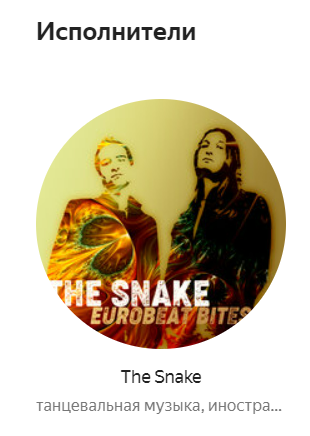

In [49]:
# Проверим дублирующиеся строки
catalog_names[catalog_names.duplicated()]

,id,type,name


In [55]:
# Проверим наличие пропусков
catalog_names[catalog_names.isna().any(axis=1)]

,id,type,name


In [83]:
# Проверим "неизвестных" исполнителей
catalog_names[catalog_names['name']=='Unknown']

,id,type,name
55033,289114,album,Unknown
76078,601828,album,Unknown
228223,3477779,album,Unknown
358680,6152730,album,Unknown
360535,6192254,album,Unknown
414186,7891127,album,Unknown
504301,11271919,album,Unknown
554625,13364758,album,Unknown
561444,13723426,album,Unknown
643164,19671631,album,Unknown


Такой исполнитель есть на я.музыке, а альбомов и треков нет.

In [85]:
catalog_names[catalog_names['name']=='unknown']

,id,type,name
524817,12116653,album,unknown
526549,12190200,album,unknown
1682761,71240864,track,unknown


С таким названием на сервисе ничего нет. Похоже, это заглушка.

In [86]:
# Посмотрим следующий датасет
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [87]:
# Выведем несколько строк
interactions.sample(3)

,user_id,track_id,track_seq,started_at
1116,1174492,83979509,1117,2022-10-12
804,909095,54108162,805,2022-11-29
123,934811,4644164,124,2022-09-16


In [88]:
# Проверим наличие пропусков
interactions[interactions.isna().any(axis=1)]

,user_id,track_id,track_seq,started_at


In [89]:
# Проверим дублирующиеся строки
interactions[interactions.duplicated()]

,user_id,track_id,track_seq,started_at


In [91]:
# Посмотрим на самую раннюю дату
interactions['started_at'].min()

Timestamp('2022-01-01 00:00:00')

In [92]:
# Посмотрим на последнюю дату
interactions['started_at'].max()

Timestamp('2022-12-31 00:00:00')

Таким образом, данные о взаимодействиям предствалены за один год.

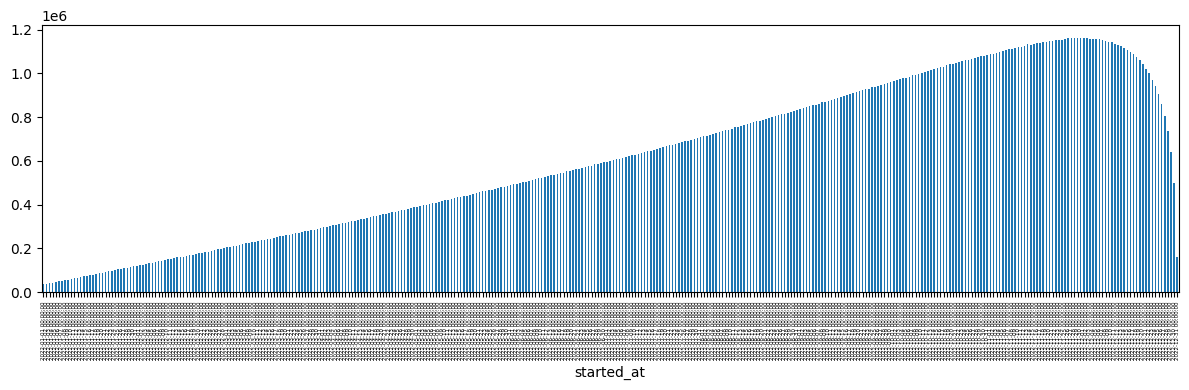

In [ ]:
# распределение событий по месяцам публикации

fig, ax = plt.subplots(figsize=(12, 4))

interactions["started_at"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=4)

fig.tight_layout()
plt.show()

In [ ]:
# Сделаем признак месяца
interactions["started_at_month"] = pd.to_datetime(interactions["started_at"]).dt.to_period('M').dt.to_timestamp().dt.date

In [6]:
# Получим датасет с количество пользователей и событий по месяцам
interactions_by_month = interactions.groupby("started_at_month").agg(events=("started_at", 
                                                                             "count"), users=("user_id", 
                                                                                              "nunique")).reset_index()

In [11]:
# Посмотрим на результат
interactions_by_month

,started_at_month,events,users
0,2022-01-01,2409541,126224
1,2022-02-01,4533363,227852
2,2022-03-01,7691225,344333
3,2022-04-01,10230295,454378
4,2022-05-01,13613489,569813
5,2022-06-01,16266558,676467
6,2022-07-01,20188819,788369
7,2022-08-01,23919641,892539
8,2022-09-01,26953965,979781
9,2022-10-01,31810464,1056636


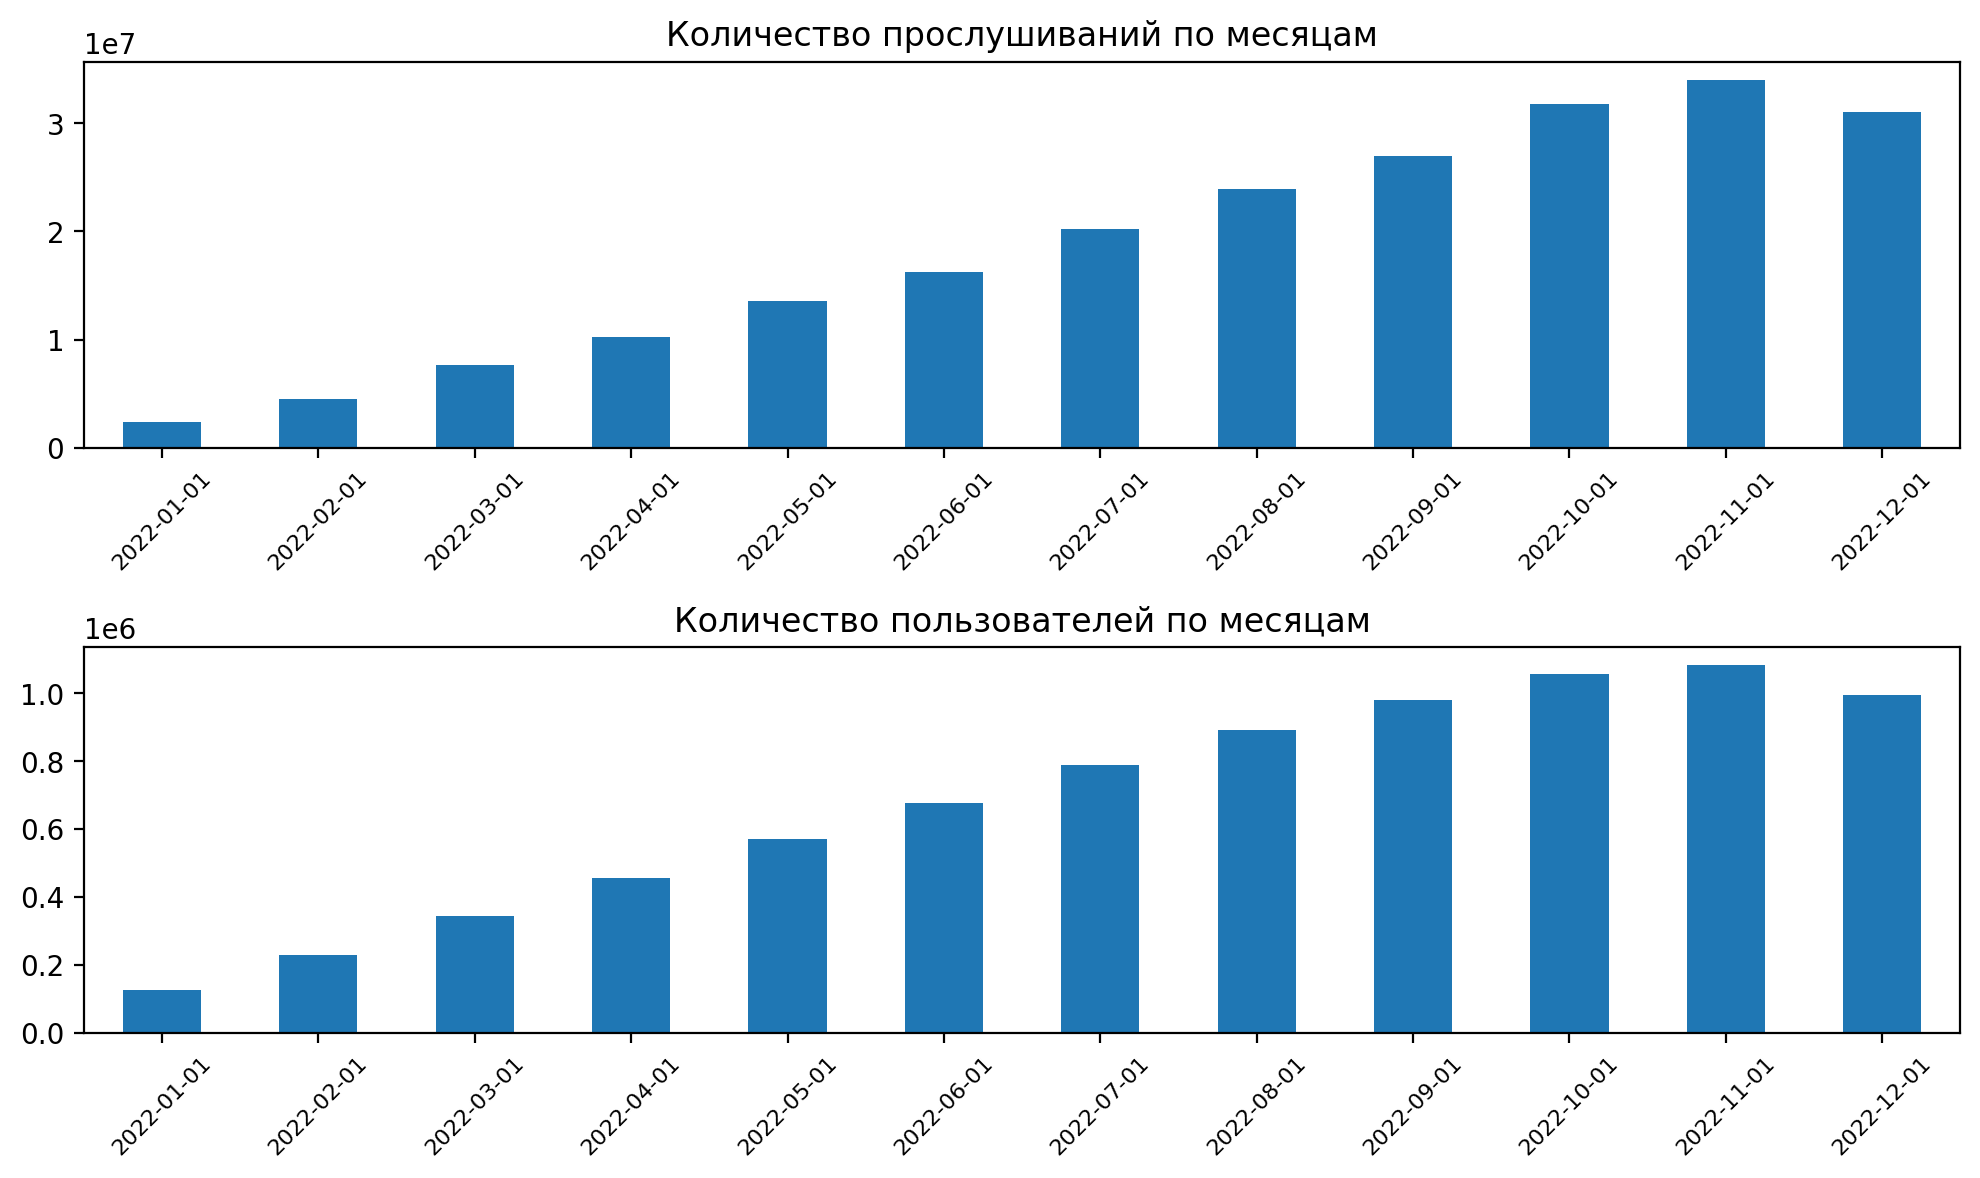

In [22]:
# Построим распределение по месяцам прослушивания

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

ax = axs[0]
interactions_by_month["events"].plot(kind="bar", ax=ax)
ax.set_title('Количество прослушиваний по месяцам')
ax.set_xticklabels(interactions_by_month['started_at_month'], rotation=45)
ax.tick_params(axis='x', labelsize=8)

ax = axs[1]
interactions_by_month["users"].plot(kind="bar", ax=ax)
ax.set_title('Количество пользователей по месяцам')
ax.set_xticklabels(interactions_by_month['started_at_month'], rotation=45)
ax.tick_params(axis='x', labelsize=8)

fig.tight_layout()

Распределение не выглядит аномально.

# Выводы

Данные о треках — в файле tracks.parquet:
- track_id — идентификатор музыкального трека;
- albums — список идентификаторов альбомов, содержащих трек;
- artists — список идентификаторов исполнителей трека;
- genres — список идентификаторов жанров, к которым принадлежит трек.

Имена артистов, названия альбомов, треков и жанров — в файле catalog_names.parquet:
- id — идентификатор одной из каталожных единиц (трека, альбома, исполнителя, жанра);
- type — тип идентификатора;
- name — имя (название) каталожной единицы.

Данные о том, какие пользователи прослушали тот или иной трек, — в файле interactions.parquet:
- user_id — идентификатор пользователя,
- track_id — идентификатор музыкального трека,
- track_seq — номер места трека в истории пользователя,
- started_at — дата начала прослушивания трека.

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

Наиболее популярные треки

Наиболее популярные жанры

Треки, которые никто не прослушал

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.